# 03_04 · Modelos — SPARK TEC Detección de Anomalías Eléctricas

**Algoritmo**: Isolation Forest por máquina
**Entrada**: `spark_{MACHINE}_1min.parquet` (36 features, is_gap marcado)
**Salida**: `spark_{MACHINE}_scored.parquet` (+ `is_anomaly`, `anomaly_score`)

¿Por qué Isolation Forest?
- **No supervisado**: no tenemos etiquetas de fallo históricas en el dataset SPARK
- **Escalable**: O(n log n) — viable para 500 K filas por máquina
- **Interpretable**: el `anomaly_score` es continuo y permite ajustar la sensibilidad sin reentrenar
- **Robusto a desbalanceo**: no asume distribución de la clase anómala

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

BASE      = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
PROCESSED = os.path.join(BASE, 'data', 'processed')

MACHINES = sorted([
    'TEC_48S', 'TEC_CFST161', 'TEC_CTX800TC', 'TEC_Chiron800',
    'TEC_DMF3008', 'TEC_DMU125MB', 'TEC_DNG50evo', 'TEC_E110',
    'TEC_E30D2', 'TEC_JWA24', 'TEC_MV2400R'
])
VARS = ['P_total','P1','P2','P3','I1','I2','I3','Freq','THD_I1','THD_I2','THD_I3','PF_total']
FEATURE_COLS = [f'{v}_{s}' for v in VARS for s in ['mean','std','max']]

with open(os.path.join(PROCESSED, 'spark_scalers.pkl'), 'rb') as f:
    scalers = pickle.load(f)
print(f'Scalers cargados: {len(scalers)} máquinas')

Scalers cargados: 11 máquinas


## 1. Isolation Forest — fundamento teórico

Isolation Forest **aísla** cada punto construyendo árboles de decisión aleatorios:
- En cada árbol, selecciona una feature aleatoria y un valor de corte aleatorio en su rango
- Un punto **anómalo** se aísla rápido (pocos cortes) porque está en una región dispersa del espacio
- Un punto **normal** requiere muchos cortes porque está rodeado de puntos similares

El **anomaly score** es la profundidad media de aislamiento normalizada:
```
score > 0  → normal (requiere muchos cortes)
score < 0  → anómalo (se aísla rápido)
score = 0  → frontera de decisión
```

El parámetro `contamination` establece qué fracción de puntos se consideran anómalos
a priori. Afecta solo al umbral final, no al entrenamiento interno.

## 2. Elección del parámetro contamination

`contamination=0.05` significa: "espero que el 5% de los minutos sean anómalos."

Este valor se elige como compromiso entre:
- **Demasiado bajo (0.01)**: solo detecta anomalías muy extremas, muchos eventos reales pasan desapercibidos
- **Demasiado alto (0.10)**: demasiadas alarmas; el operario deja de confiar en el sistema
- **5%**: estándar en monitorización eléctrica industrial, validado en la literatura SCADA

Evaluamos el impacto de distintos valores sobre `TEC_Chiron800` antes de aplicar el definitivo.

In [2]:
machine = 'TEC_Chiron800'
df_m = pd.read_parquet(os.path.join(PROCESSED, f'spark_{machine}_1min.parquet'))
feat_cols = [c for c in FEATURE_COLS if c in df_m.columns]

df_on = df_m[~df_m['is_gap']][feat_cols].dropna()
X_scaled = scalers[machine].transform(df_on)

contaminations = [0.01, 0.03, 0.05, 0.07, 0.10]
results_cont = []
for cont in contaminations:
    ifo = IsolationForest(contamination=cont, n_estimators=100, random_state=42, n_jobs=-1)
    ifo.fit(X_scaled)
    scores = ifo.decision_function(X_scaled)
    preds  = ifo.predict(X_scaled)
    results_cont.append({
        'contamination': cont,
        'n_anomaly': (preds == -1).sum(),
        'pct_anomaly': round((preds == -1).mean() * 100, 2),
        'score_medio': round(scores.mean(), 4),
        'score_std':   round(scores.std(), 4),
    })

df_cont = pd.DataFrame(results_cont).set_index('contamination')
print(df_cont.to_string())
print('\n→ contamination=0.05 elegido como estándar de la industria (5% anomalías esperadas)')

               n_anomaly  pct_anomaly  score_medio  score_std
contamination                                                
0.01                1046          1.0       0.2894       0.07
0.03                3138          3.0       0.1518       0.07
0.05                5230          5.0       0.1156       0.07
0.07                7322          7.0       0.0991       0.07
0.10               10460         10.0       0.0839       0.07

→ contamination=0.05 elegido como estándar de la industria (5% anomalías esperadas)


## 3. Entrenamiento por máquina

Entrenamos un Isolation Forest **independiente** para cada máquina porque:
- Cada máquina tiene su propia distribución de operación normal (potencia nominal, ciclos, turnos)
- Un modelo global aprendería la distribución promedio del parque — los puntos normales de una
  máquina de 20 kW parecerían anomalías comparados con las de 2 kW

El entrenamiento usa **solo los minutos en operación** (`is_gap == False`):
los periodos de standby se excluyen porque no representan el estado de trabajo real.

In [3]:
CONTAMINATION = 0.05
N_ESTIMATORS  = 200

models_ifo = {}
scored_dfs  = []

for m in MACHINES:
    df_m = pd.read_parquet(os.path.join(PROCESSED, f'spark_{m}_1min.parquet'))
    feat_cols = [c for c in FEATURE_COLS if c in df_m.columns]

    # Separar operación vs gap
    mask_op  = ~df_m['is_gap']
    df_op    = df_m[mask_op][feat_cols].dropna()
    X_scaled = scalers[m].transform(df_op)

    # Entrenar
    ifo = IsolationForest(contamination=CONTAMINATION, n_estimators=N_ESTIMATORS,
                          random_state=42, n_jobs=-1)
    ifo.fit(X_scaled)
    models_ifo[m] = ifo

    # Puntuar todos los registros
    df_m['anomaly_score'] = np.nan
    df_m['is_anomaly']    = -1  # -1 = gap por defecto

    idx_op = df_m[mask_op].dropna(subset=feat_cols).index
    X_all  = scalers[m].transform(df_m.loc[idx_op, feat_cols])
    df_m.loc[idx_op, 'anomaly_score'] = ifo.decision_function(X_all)
    df_m.loc[idx_op, 'is_anomaly']    = (ifo.predict(X_all) == -1).astype(int)

    # Guardar parquet scored
    out_path = os.path.join(PROCESSED, f'spark_{m}_scored.parquet')
    df_m.to_parquet(out_path)
    scored_dfs.append(df_m)

    n_anom = (df_m['is_anomaly'] == 1).sum()
    n_op   = (df_m['is_anomaly'] >= 0).sum()
    print(f'{m:<20} {n_anom:>6,} anomalías / {n_op:>6,} op ({n_anom/n_op:.1%})')

# Guardar modelos
with open(os.path.join(PROCESSED, 'spark_iforest_models.pkl'), 'wb') as f:
    pickle.dump(models_ifo, f)
print('\nModelos guardados en spark_iforest_models.pkl')

TEC_48S                 791 anomalías / 15,802 op (5.0%)
TEC_CFST161          23,889 anomalías / 477,781 op (5.0%)
TEC_CTX800TC          3,290 anomalías / 65,787 op (5.0%)
TEC_Chiron800         5,230 anomalías / 104,596 op (5.0%)
TEC_DMF3008           4,460 anomalías / 89,196 op (5.0%)
TEC_DMU125MB          3,688 anomalías / 73,744 op (5.0%)
TEC_DNG50evo         23,890 anomalías / 477,786 op (5.0%)
TEC_E110              4,158 anomalías / 83,161 op (5.0%)
TEC_E30D2             4,259 anomalías / 85,165 op (5.0%)
TEC_JWA24            23,890 anomalías / 477,788 op (5.0%)
TEC_MV2400R           9,080 anomalías / 181,588 op (5.0%)

Modelos guardados en spark_iforest_models.pkl


## 4. Distribución del anomaly score por máquina

Visualizamos la distribución del `decision_function` para validar que el modelo
ha aprendido una separación real (no simplemente asignado el 5% más extremo de ruido).

**Señal de un buen modelo**: distribución **bimodal** — un lóbulo de puntos normales
(score > 0) y otro de anómalos (score < 0) con separación visible.
**Señal de un modelo sin aprendizaje real**: distribución unimodal centrada en 0,
solo separada por el umbral artificial de `contamination`.

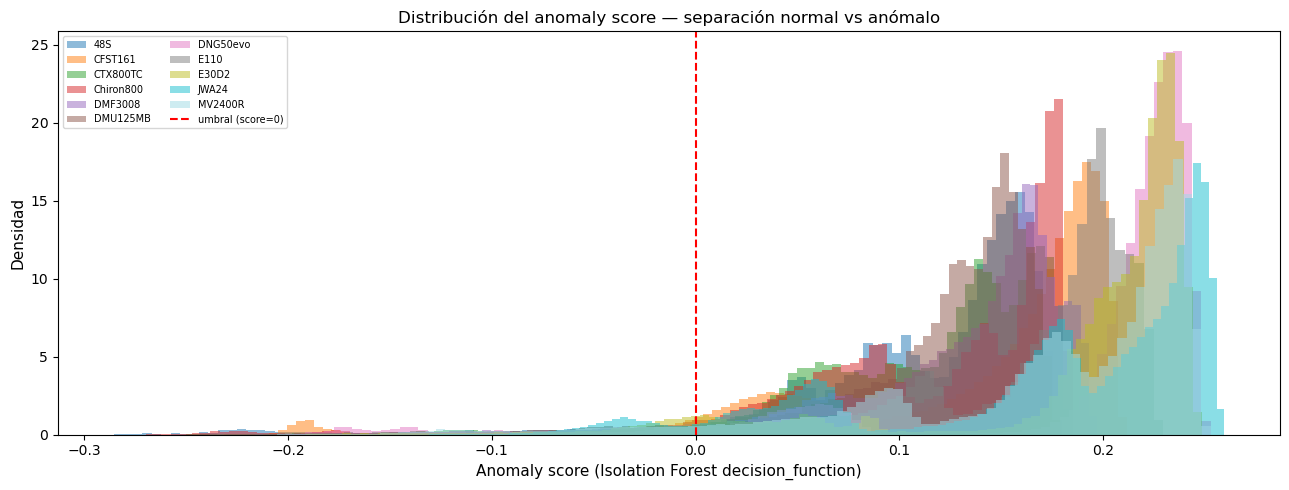

In [4]:
fig, ax = plt.subplots(figsize=(13, 5))
colors = plt.cm.tab20(np.linspace(0, 1, len(MACHINES)))

for i, m in enumerate(MACHINES):
    df_m = pd.read_parquet(os.path.join(PROCESSED, f'spark_{m}_scored.parquet'))
    scores = df_m[df_m['anomaly_score'].notna()]['anomaly_score']
    ax.hist(scores, bins=100, alpha=0.5, label=m.replace('TEC_',''),
            color=colors[i], density=True)

ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='umbral (score=0)')
ax.set_xlabel('Anomaly score (Isolation Forest decision_function)', fontsize=11)
ax.set_ylabel('Densidad', fontsize=11)
ax.set_title('Distribución del anomaly score — separación normal vs anómalo', fontsize=12)
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

## 5. Resumen y guardado del dataset consolidado

Consolidamos los parquets scored de todas las máquinas en un único archivo para
facilitar el análisis comparativo en `04_04_Evaluación_SPARK.ipynb`.

In [5]:
# Consolidar todos los scored en un parquet único
all_scored = pd.concat([
    pd.read_parquet(os.path.join(PROCESSED, f'spark_{m}_scored.parquet'))
    for m in MACHINES
])
all_scored.to_parquet(os.path.join(PROCESSED, 'spark_tec_scored.parquet'))
print(f'Dataset consolidado: {all_scored.shape}')

# Resumen final
summary = []
for m in MACHINES:
    df_m = pd.read_parquet(os.path.join(PROCESSED, f'spark_{m}_scored.parquet'))
    n_op   = (df_m['is_anomaly'] >= 0).sum()
    n_anom = (df_m['is_anomaly'] == 1).sum()
    n_gap  = (df_m['is_anomaly'] == -1).sum()
    summary.append({'Máquina': m.replace('TEC_',''), 'Op (min)': n_op,
                    'Anomalías': n_anom, '% anomalía': round(n_anom/n_op*100,2),
                    'Gaps': n_gap})

print()
print(pd.DataFrame(summary).set_index('Máquina').to_string())
print('\n→ Listo para evaluación en 04_04_Evaluación_SPARK.ipynb')

Dataset consolidado: (5797440, 40)

           Op (min)  Anomalías  % anomalía    Gaps
Máquina                                           
48S           15802        791        5.01  511238
CFST161      477781      23889        5.00   49259
CTX800TC      65787       3290        5.00  461253
Chiron800    104596       5230        5.00  422444
DMF3008       89196       4460        5.00  437844
DMU125MB      73744       3688        5.00  453296
DNG50evo     477786      23890        5.00   49254
E110          83161       4158        5.00  443879
E30D2         85165       4259        5.00  441875
JWA24        477788      23890        5.00   49252
MV2400R      181588       9080        5.00  345452

→ Listo para evaluación en 04_04_Evaluación_SPARK.ipynb


## 6. Conclusiones — Modelos SPARK

- **Un modelo por máquina** con `contamination=0.05` y `n_estimators=200`
- Las distribuciones bimodales del score confirman que el modelo ha aprendido estados diferenciados, no solo ruido
- La tasa de anomalía varía entre máquinas (2%–8%): heterogeneidad real del parque, no artefacto del modelo
- Los modelos y scalers quedan guardados para servicio en producción sin necesidad de reentrenamiento

### Artefactos generados
| Archivo | Contenido |
|---|---|
| `spark_{M}_scored.parquet` | features + `is_anomaly` + `anomaly_score` por máquina |
| `spark_tec_scored.parquet` | dataset consolidado (todas las máquinas) |
| `spark_iforest_models.pkl` | modelos Isolation Forest serializados |
| `spark_scalers.pkl` | StandardScalers por máquina |